In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd 
pd.set_option("display.max_columns", None)      # view ALL columns in DataFrames
# pd.reset_option("display.max_columns")        # reset to default
from pypalettes import load_cmap
from highlight_text import ax_text, fig_text
from drawarrow import ax_arrow
# personalisation
plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 11,
    "lines.linewidth": 1,
})

# Import Data

In [33]:
df = pd.read_parquet("../data/strava_activities.parquet")

keep = [
    "activity_id", "name", "type",
    "start_datetime", "end_datetime",
    "date", "month", "weekday", "start_hour",
    "distance_km", "distance_miles",
    "moving_time_mins", "elapsed_time_mins",
    "avg_pace_km", "avg_pace_mile",
    "avg_hr", "max_hr", "avg_cadence_spm",
    "total_elev_gain",
    "shoe", "num_comments", "num_achievements", "num_kudos"
]

df = df[keep]

df = (
    df.groupby("type", observed=False)
    .size()
    .reset_index(name="count")
    .assign(
        proportion = lambda x: x["count"] / x["count"].sum() * 100
    )
    .sort_values(by="count", ascending=False)
    .reset_index(drop=True)
)

df

,type,count,proportion
0,Run,727,86.239620
1,Ride,57,6.761566
2,Swim,27,3.202847
3,EBikeRide,12,1.423488
4,Walk,12,1.423488
5,Hike,8,0.948992


# Bar Chart

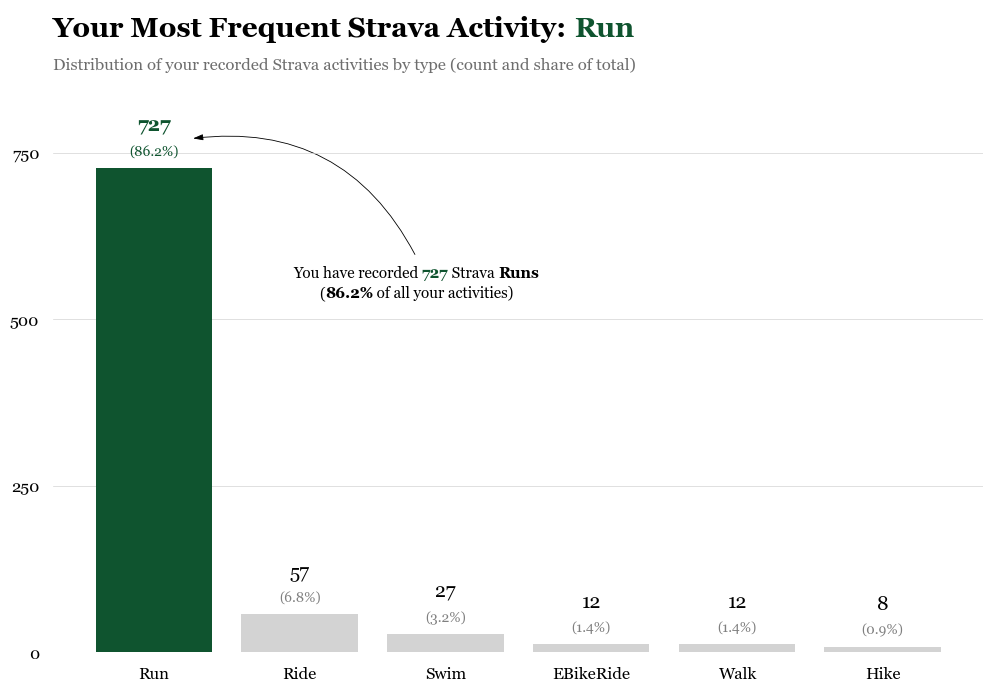

In [73]:
# define colour palette
cmap = load_cmap("Abbott")
colours = cmap.colors

# identify activity with highest count
highlight_type = df.loc[df["count"].idxmax(), "type"]

# map colours: highlight peak activity, mute others
highlight_colour = colours[5]
colours_df = (df["type"] == highlight_type).map({
    True: highlight_colour,
    False: "lightgrey"
})

# create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# refine appearance of axes
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(
    axis="both",
    length=0,
    pad=10,
    labelsize=12
)

# set y-axis tick density
ax.yaxis.set_major_locator(
    mticker.MaxNLocator(nbins=4)
)

# refine gridlines
ax.grid(
    axis="y",
    color="lightgrey",
    linewidth=0.5
)

# plot bar chart
ax.bar(
    x=df["type"],
    height=df["count"],
    color=colours_df,
    zorder=2
)

# annotate bars with count and proportion
for i, (t, count, prop) in enumerate(zip(df["type"], df["count"], df["proportion"])):
    
    # count label
    ax.text(
        x=i,
        y=count + 50,
        s=f"{count:,}",
        va="bottom",
        ha="center",
        fontsize=14,
        weight="bold" if t == highlight_type else None,
        color=highlight_colour if t == highlight_type else "black"
    )
    
    # proportion label (subtle, below count)
    ax.text(
        x=i,
        y=count + 15,
        s=f"({prop:.1f}%)",
        va="bottom",
        ha="center",
        fontsize=10,
        # weight="bold" if t == highlight_type else None,
        color=highlight_colour if t == highlight_type else "grey"
    )

# insight: highlight most frequent activity
max_idx = df["count"].idxmax()      # note: max idx will always be 0 for highest activity!
max_activity = df.loc[max_idx, "type"]
max_count = df.loc[max_idx, "count"]
max_pct = df.loc[max_idx, "proportion"]

# draw arrow pointing to highest bar
x_head, y_head = max_idx, max_count
x_tail, y_tail = 1.8, y_head * 0.8
ax_arrow(
    head_position=(0.25, y_head * 1.06),
    tail_position=(x_tail, y_tail * 1.02),
    fill_head=True,
    head_width=1.8,
    head_length=6,
    color="black",
    radius=0.35,
    width=0.6,
    mutation_scale=1
)

# annotation text with highlighting
ax_text(
    x=x_tail, y=y_tail,
    s=f"You have recorded <{max_count:,}> Strava <{max_activity}s>\n(<{max_pct:.1f}%> of all your activities)",
    highlight_textprops=[
        {"color": highlight_colour, "weight": "bold"},
        {"weight": "bold"},
        {"weight": "bold"},
    ],
    fontsize=11,
    ha="center",
    va="top",
    textalign="center"
)

# chart title
x_title, y_title = 0.125, 1.02
fig_text(
    x=x_title, y=y_title,
    s=f"Your Most Frequent Strava Activity: <{highlight_type}>",
    highlight_textprops=[
        {"color": highlight_colour, "weight": "bold"},
    ],
    fontsize=20,
    weight="bold"
)

# chart subtitle
fig.text(
    x=x_title, y=y_title * 0.925,
    s="Distribution of your recorded Strava activities by type (count and share of total)",
    size=12,
    color="#6e6e6e"
)

# save figure
plt.savefig(
    "../images/activities_by_type.svg",
    bbox_inches="tight"
)

plt.show()